# Unemployment Rate Forecasting — Republic of Kazakhstan

**Objective:** Forecast the monthly unemployment rate $y_t$ using structural labor
market indicators and econometric methods.

| Split | Period | $n$ |
|-------|--------|-----|
| **Train** | 2015-01 $\to$ 2023-12 | 108 |
| **Test**  | 2024-01 $\to$ 2025-12 | 24  |

**Models (8):** SARIMA · SARIMAX · ARDL · Elastic Net · Ridge · Lasso · ANN (MLP) · RNN (LSTM)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings, re
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':     'serif',
    'mathtext.fontset':'cm',
    'axes.labelsize':  12,
    'font.size':       11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize':  (12, 5),
    'axes.grid':       True,
    'grid.alpha':      0.3,
    'figure.dpi':      130,
    'savefig.dpi':     300,
    'savefig.bbox':    'tight',
})

DATA = '../../data/'
print("Libraries loaded.")

Libraries loaded.


## 1 $\cdot$ Data Loading

Structural unemployment indicators are loaded from Kazakhstan Bureau of National
Statistics Excel files.  Annual series are PCHIP-interpolated to monthly frequency.
Brent crude oil prices are fetched from Yahoo Finance; the USD/KZT exchange rate
is read from the local `USD_TENGE.xlsx` file.

In [2]:
import yfinance as yf

def clean_annual(filepath, col_name):
    df = pd.read_excel(filepath, skiprows=10)
    row = df[df.iloc[:, 0].astype(str).str.contains('\u0420\u0415\u0421\u041f\u0423\u0411\u041b\u0418\u041a\u0410', na=False)].copy()
    if row.empty:
        raise ValueError(f"Header row not found in {filepath}")
    row = row.drop(row.columns[0], axis=1).T
    row.columns = [col_name]
    row.index = row.index.astype(str).str.extract(r'(\d{4})')[0]
    row.index = pd.to_datetime(row.index + '-01-01')
    row[col_name] = row[col_name].astype(str).str.replace(r'\s+', '', regex=True)
    row[col_name] = pd.to_numeric(row[col_name], errors='coerce')
    return row.resample('MS').interpolate(method='pchip')

# --- Sectoral employment ---
df_agr   = clean_annual(DATA + 'unemp/agricultural.xls',    'Agri_Emp')
df_ind   = clean_annual(DATA + 'unemp/infrastructure.xls',  'Ind_Emp')
df_serv  = clean_annual(DATA + 'unemp/services.xls',        'Serv_Emp')
df_wage  = clean_annual(DATA + 'unemp/avg_salary.xls',      'Nominal_Wage')
df_labor = clean_annual(DATA + 'labor_force.xls',           'LaborForce')

# --- Brent Oil (monthly, yfinance) ---
_brent = yf.download('BZ=F', start='2001-01-01', progress=False)
df_energy = _brent[['Close']].resample('MS').mean().ffill()
df_energy.columns = ['Brent_Oil_Price']
df_energy.index.name = 'Date'

# --- USD/KZT exchange rate (local xlsx, daily -> monthly mean) ---
_usd = pd.read_excel(DATA + 'USD_TENGE.xlsx')
_date = pd.to_datetime(_usd.iloc[:, 0], dayfirst=True)
_quant = pd.to_numeric(_usd.iloc[:, 1], errors='coerce').fillna(1)
_tenge = pd.to_numeric(_usd.iloc[:, 2], errors='coerce')
df_exchange = pd.DataFrame({'USD_KZT': (_tenge / _quant).values}, index=_date)
df_exchange = df_exchange.sort_index().resample('MS').mean().ffill()

# --- Target: Unemployment rate ---
df_target = pd.read_excel(
    DATA + 'unemployment_rate.xlsx',
    sheet_name='unemployed_rate', parse_dates=['Date']
).set_index('Date')
df_target.columns = ['unemployed_rate']

print('Loaded datasets:')
for name, d in [('Agri_Emp', df_agr), ('Ind_Emp', df_ind), ('Serv_Emp', df_serv),
                ('Nominal_Wage', df_wage), ('LaborForce', df_labor),
                ('Brent_Oil_Price', df_energy), ('USD_KZT', df_exchange),
                ('unemployed_rate', df_target)]:
    print(f'  {name:20s}  {d.index.min().date()} -> {d.index.max().date()}  ({len(d)} obs)')

Loaded datasets:
  Agri_Emp              2001-01-01 -> 2024-01-01  (277 obs)
  Ind_Emp               2001-01-01 -> 2024-01-01  (277 obs)
  Serv_Emp              2001-01-01 -> 2024-01-01  (277 obs)
  Nominal_Wage          2012-01-01 -> 2024-01-01  (145 obs)
  LaborForce            2001-01-01 -> 2024-01-01  (277 obs)
  Brent_Oil_Price       2007-07-01 -> 2026-03-01  (225 obs)
  USD_KZT               2010-03-01 -> 2026-03-01  (193 obs)
  unemployed_rate       2010-01-01 -> 2025-12-01  (192 obs)


## 2 $\cdot$ Data Preparation & Missing-Value Treatment

All indicator series are merged on a common monthly `DatetimeIndex`.  Only the
date range where the target variable (unemployment rate) is observed is retained.
Forward-fill is applied to indicators whose latest observation lags behind the
target range (e.g.\ exchange rate weekends, delayed statistical releases).

In [3]:
indicators = [df_agr, df_ind, df_serv, df_wage, df_labor, df_energy, df_exchange]
for ind in indicators:
    ind.index.name = 'Date'
df_target.index.name = 'Date'

df_master = pd.concat(indicators + [df_target], axis=1)
df_master = df_master.loc[df_master['unemployed_rate'].notna()].copy()
df_master = df_master.ffill().bfill()

print(f"Master dataset: {df_master.shape[0]} months x {df_master.shape[1]} columns")
print(f"Date range: {df_master.index.min().date()} -> {df_master.index.max().date()}")
print(f"\nMissing values:\n{df_master.isna().sum()}")
df_master.head()

Master dataset: 192 months x 8 columns
Date range: 2010-01-01 -> 2025-12-01

Missing values:
Agri_Emp           0
Ind_Emp            0
Serv_Emp           0
Nominal_Wage       0
LaborForce         0
Brent_Oil_Price    0
USD_KZT            0
unemployed_rate    0
dtype: int64


,Agri_Emp,Ind_Emp,Serv_Emp,Nominal_Wage,LaborForce,Brent_Oil_Price,USD_KZT,unemployed_rate
Date,,,,,,,,
2010-01-01,2.294932e+06,1.518590e+06,4.300643e+06,101263.0,8.610729e+06,77.008421,147.100323,6.3
2010-02-01,2.293163e+06,1.522870e+06,4.317747e+06,101263.0,8.624116e+06,74.909999,147.100323,6.2
2010-03-01,2.288844e+06,1.526783e+06,4.334473e+06,101263.0,8.636153e+06,79.931304,147.100323,6.1
2010-04-01,2.281592e+06,1.531177e+06,4.354118e+06,101263.0,8.649465e+06,85.753810,146.712667,6.0
2010-05-01,2.272637e+06,1.535499e+06,4.373974e+06,101263.0,8.662378e+06,76.664737,146.679032,5.8


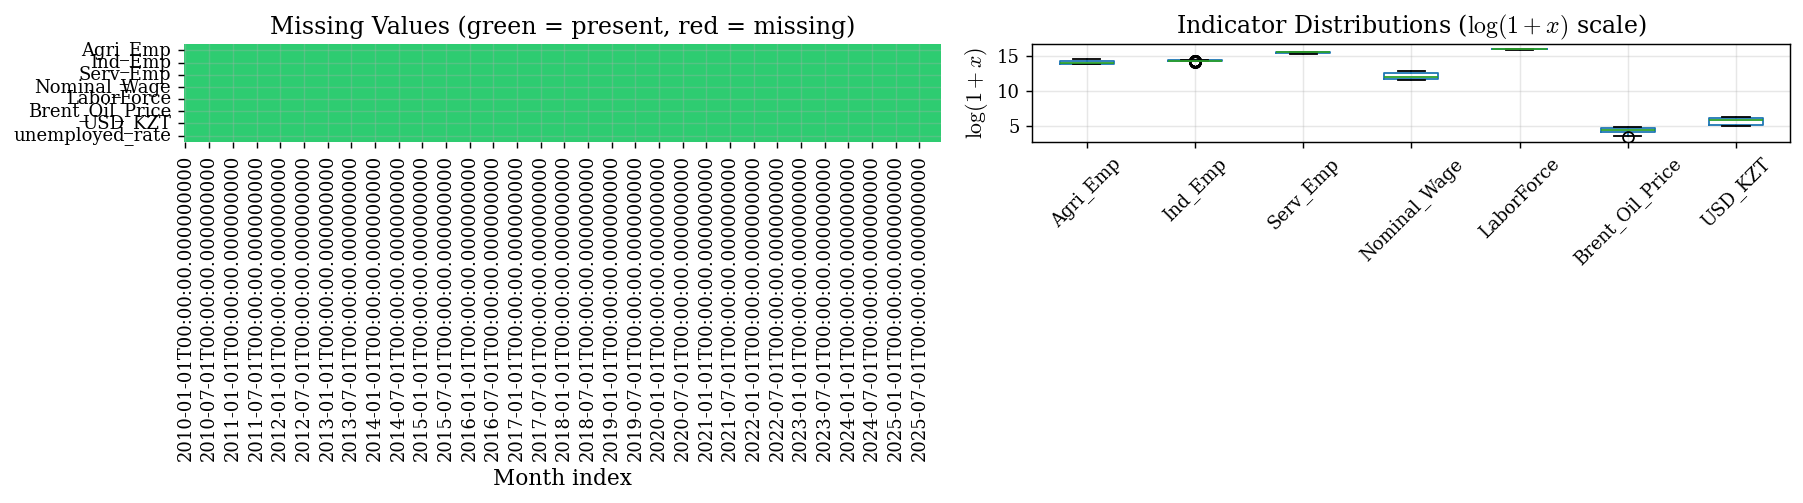

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Missing-value matrix
ax = axes[0]
sns.heatmap(df_master.isna().T, cbar=False, yticklabels=True,
            cmap=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Missing Values (green = present, red = missing)')
ax.set_xlabel('Month index')

# Box-plot of indicator scales (log)
ax = axes[1]
df_log = np.log1p(df_master.drop(columns='unemployed_rate'))
df_log.boxplot(ax=ax, rot=45)
ax.set_title(r'Indicator Distributions ($\log(1+x)$ scale)')
ax.set_ylabel(r'$\log(1+x)$')

plt.tight_layout()
plt.show()

## 3 $\cdot$ Exploratory Data Analysis

### 3.1 Descriptive Statistics

In [5]:
df_master.describe().round(2)

,Agri_Emp,Ind_Emp,Serv_Emp,Nominal_Wage,LaborForce,Brent_Oil_Price,USD_KZT,unemployed_rate
count,192.00,192.00,192.00,192.00,192.00,192.00,192.00,192.00
mean,1427796.26,1730986.41,5565122.19,211734.21,9178492.96,77.70,321.13,5.00
std,422524.75,71897.36,619406.97,110348.47,288903.38,23.47,132.03,0.31
min,1027851.00,1518590.00,4300643.00,101263.00,8610729.00,26.63,145.45,4.60
25%,1112157.81,1714458.17,5130942.87,120850.85,8980644.82,61.46,154.60,4.80
50%,1230964.32,1738255.33,5733415.75,162018.24,9134271.34,75.44,338.99,4.90
75%,1612925.97,1772413.63,6070878.58,305979.76,9420738.52,97.87,433.46,5.12
max,2294932.00,1823276.00,6363057.00,405416.00,9663991.00,124.54,540.75,6.30


### 3.2 Time-Series Visualisation

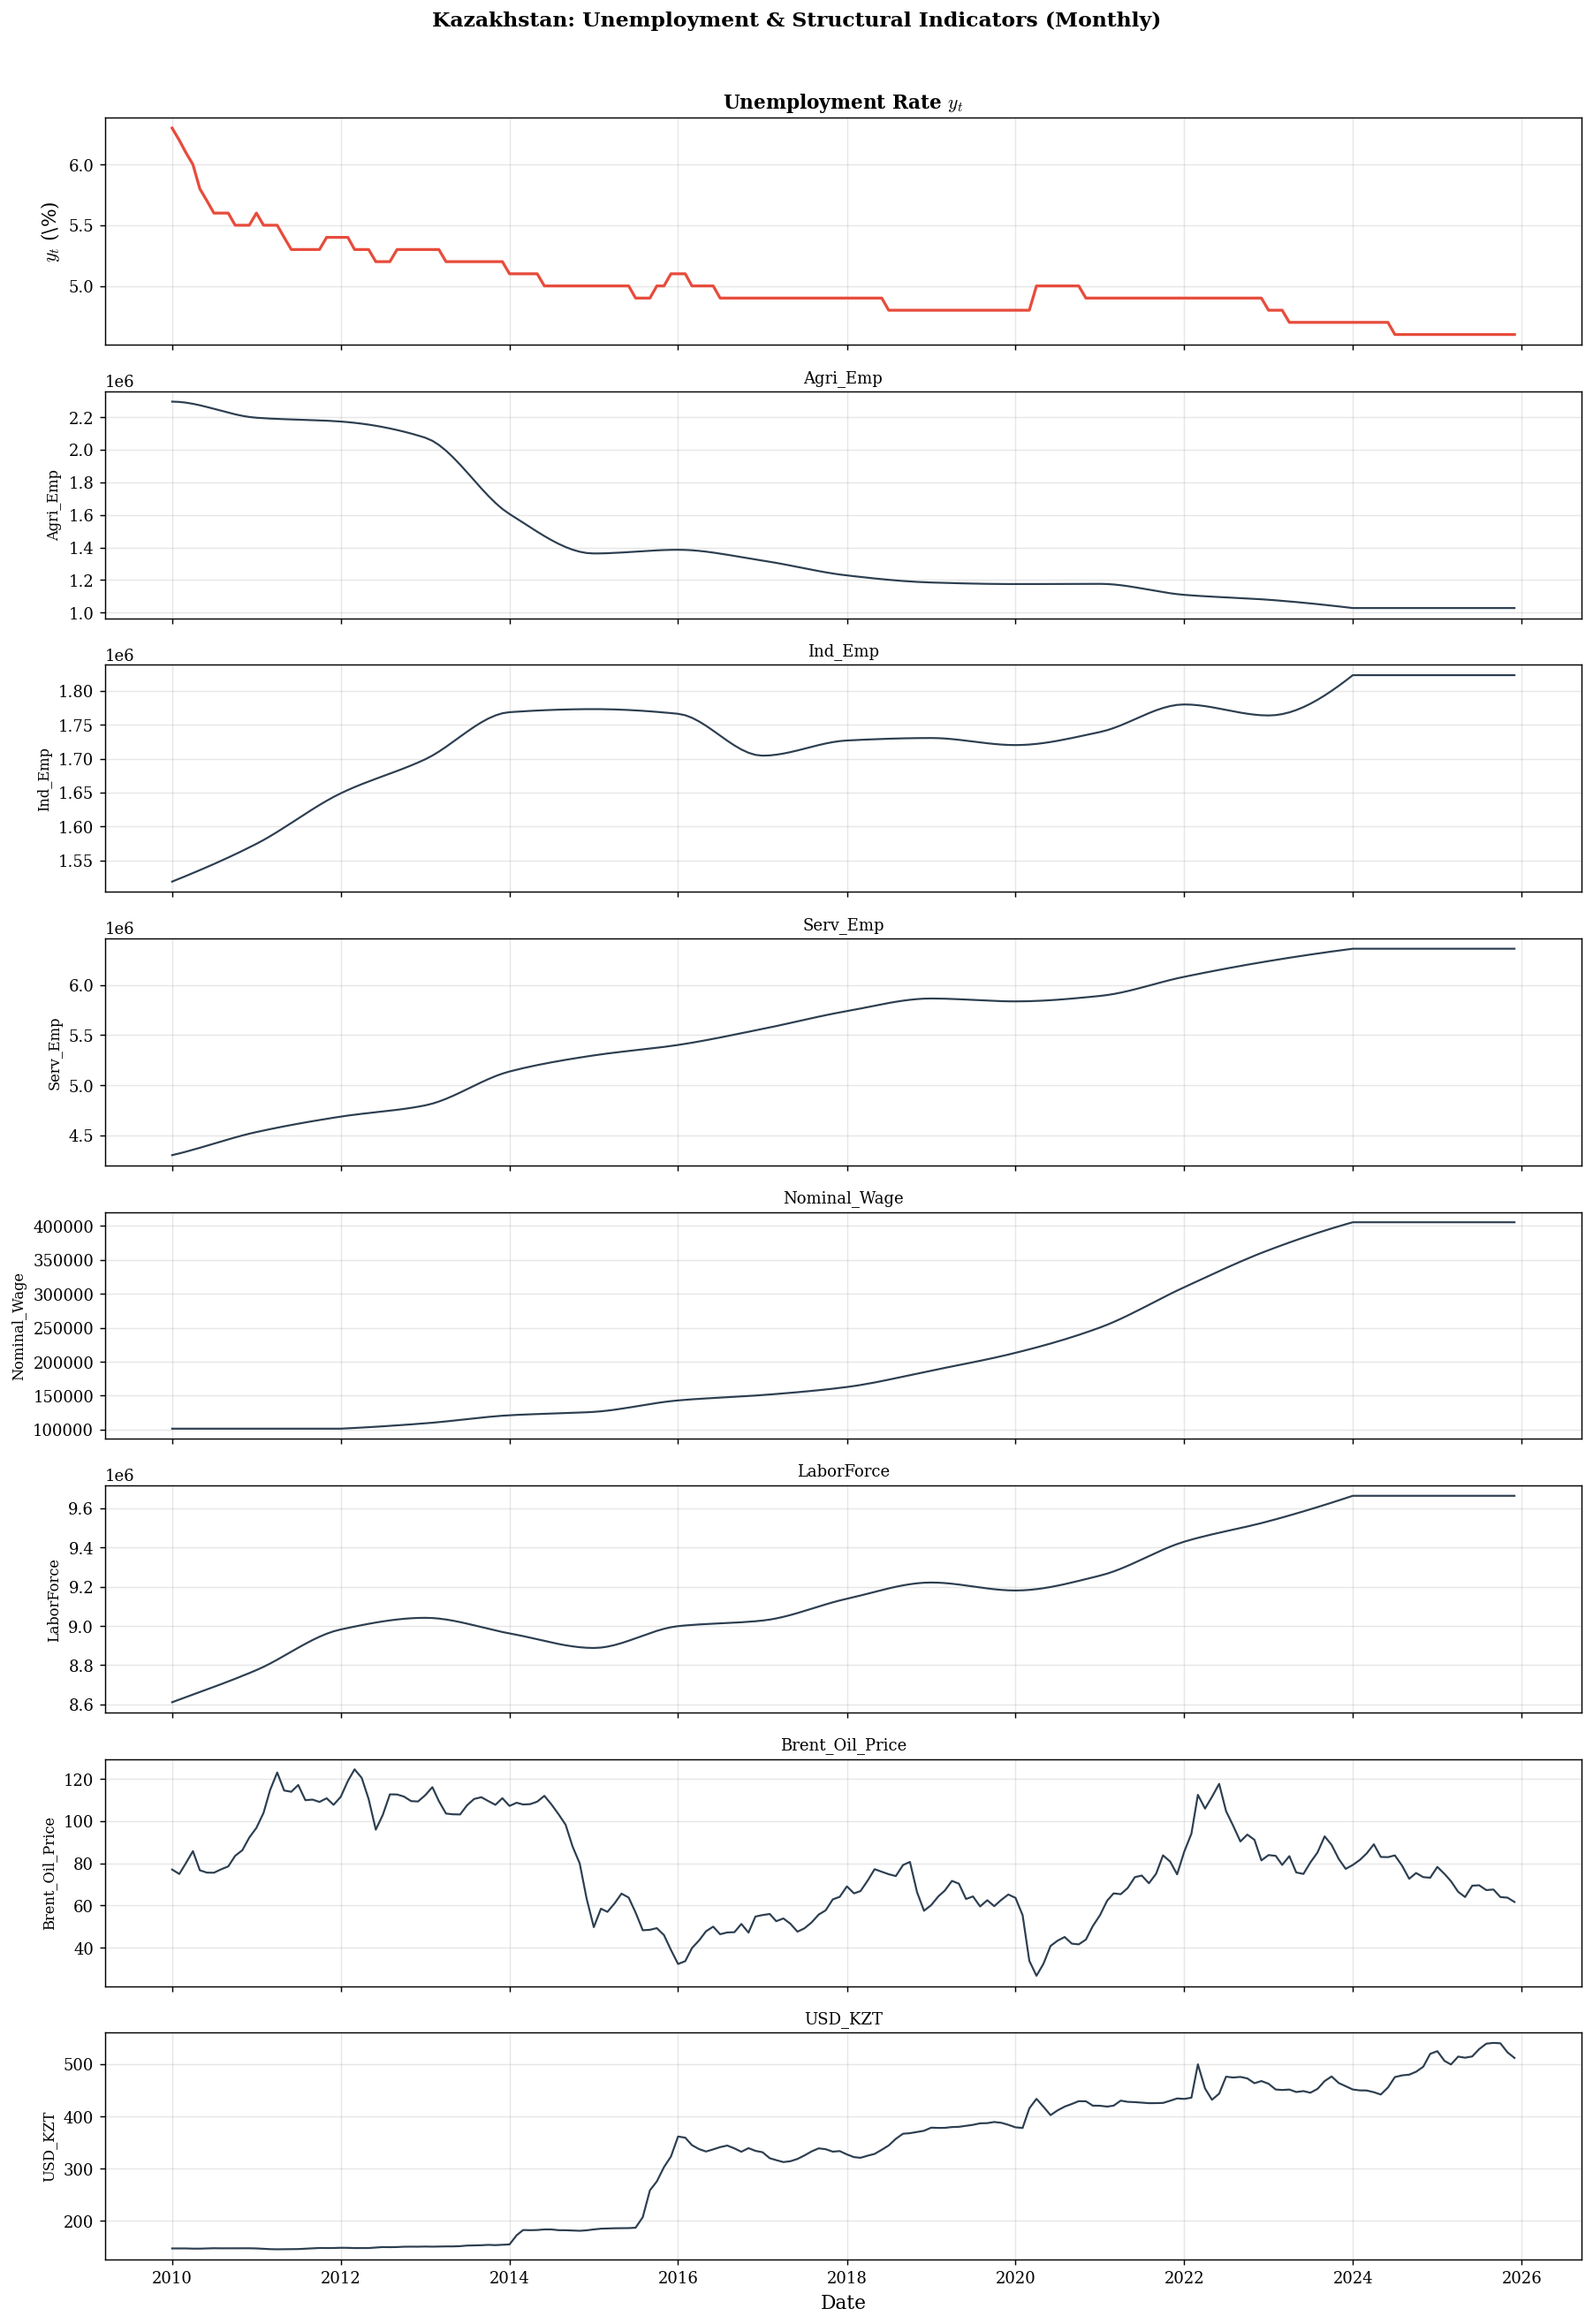

In [6]:
cols = [c for c in df_master.columns if c != 'unemployed_rate']
n = len(cols) + 1
fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n), sharex=True)

ax = axes[0]
ax.plot(df_master.index, df_master['unemployed_rate'], color='#e74c3c', lw=1.8)
ax.set_ylabel(r'$y_t$ (\%)')
ax.set_title(r'Unemployment Rate $y_t$', fontsize=12, fontweight='bold')

for i, col in enumerate(cols, 1):
    ax = axes[i]
    ax.plot(df_master.index, df_master[col], color='#2c3e50', lw=1.2)
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(col, fontsize=10)

axes[-1].set_xlabel('Date')
plt.suptitle('Kazakhstan: Unemployment & Structural Indicators (Monthly)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Correlation Analysis

Pearson correlation coefficient $\rho_{xy}$ is computed on **levels** (non-stationary)
and **first-differences** (stationary) to distinguish spurious from genuine
co-movement.

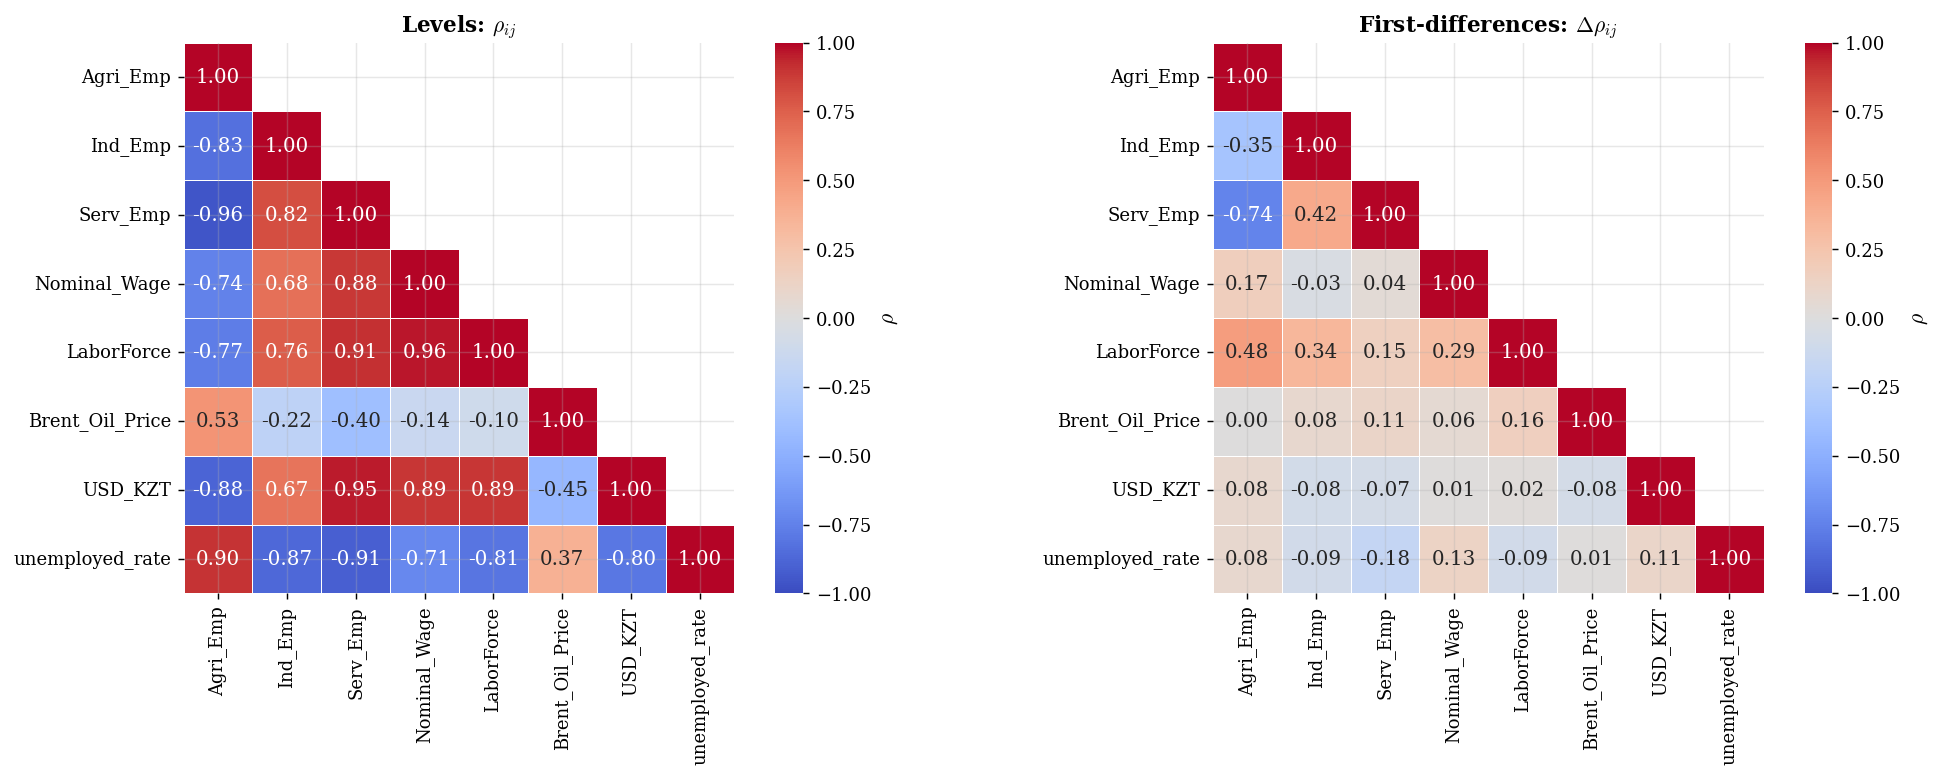


Correlation with unemployed_rate (first-differences):
Serv_Emp          -0.175007
LaborForce        -0.092277
Ind_Emp           -0.086174
Brent_Oil_Price    0.008366
Agri_Emp           0.078203
USD_KZT            0.105142
Nominal_Wage       0.128927
Name: unemployed_rate, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, data) in zip(axes, [
    (r'Levels: $\rho_{ij}$', df_master),
    (r'First-differences: $\Delta\rho_{ij}$', df_master.diff().dropna()),
]):
    corr = data.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, square=True, ax=ax,
                linewidths=.5, cbar_kws={'label': r'$\rho$'})
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCorrelation with unemployed_rate (first-differences):")
print(df_master.diff().dropna().corr()['unemployed_rate'].drop('unemployed_rate').sort_values())

### 3.4 Stationarity Testing (Augmented Dickey-Fuller)

The ADF test checks $H_0$: unit root (non-stationary) vs $H_1$: stationary.
Reject $H_0$ when $p < 0.05$.

In [8]:
results = []
for col in df_master.columns:
    s = df_master[col].dropna()
    stat, p, *_ = adfuller(s, autolag='AIC')
    results.append({
        'Variable': col,
        'ADF Statistic': round(stat, 3),
        'p-value': round(p, 4),
        'Stationary': 'Yes' if p < 0.05 else 'No'
    })
adf_df = pd.DataFrame(results).set_index('Variable')
print(adf_df.to_string())

                 ADF Statistic  p-value Stationary
Variable                                          
Agri_Emp                -2.954   0.0394        Yes
Ind_Emp                 -2.672   0.0789         No
Serv_Emp                -2.795   0.0590         No
Nominal_Wage            -1.665   0.4491         No
LaborForce              -0.882   0.7937         No
Brent_Oil_Price         -1.872   0.3452         No
USD_KZT                 -0.426   0.9057         No
unemployed_rate         -5.771   0.0000        Yes


### 3.5 Seasonal Decomposition (Unemployment Rate)

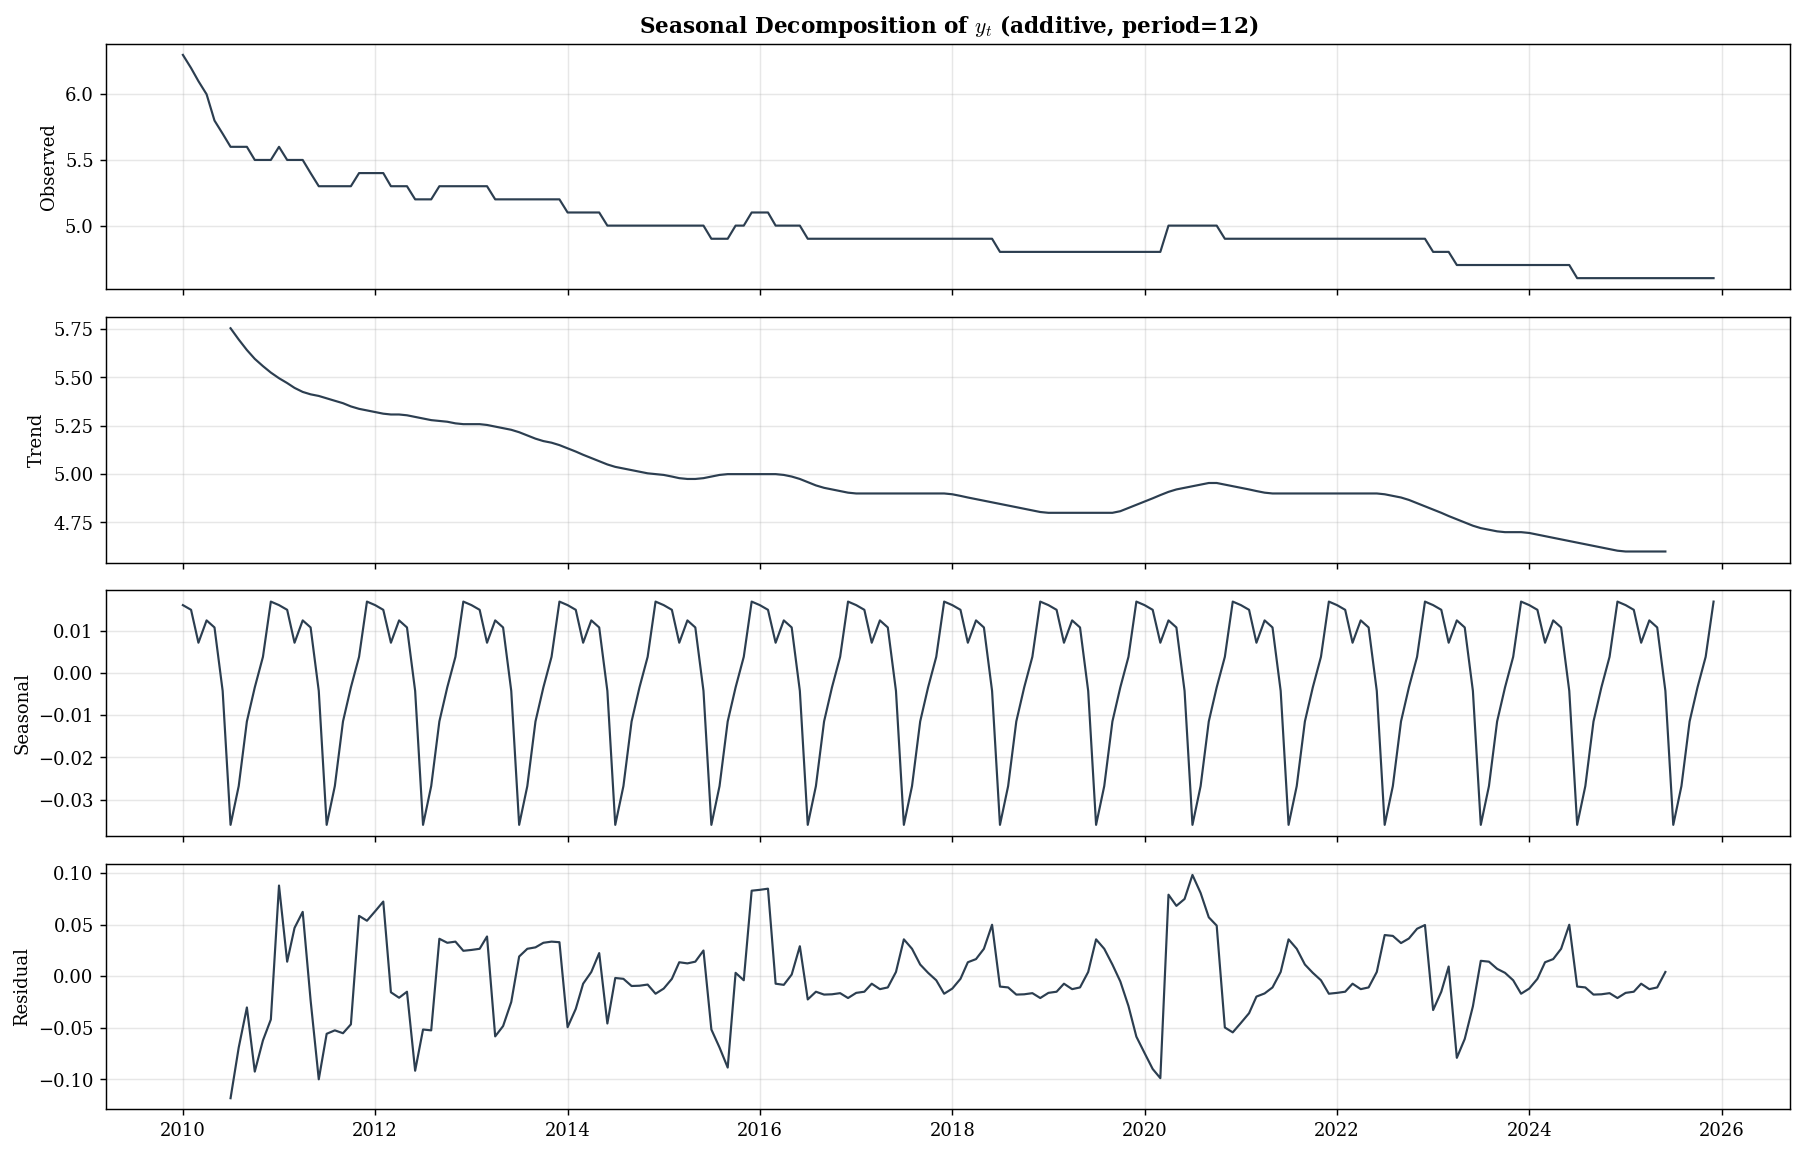

In [9]:
decomp = seasonal_decompose(df_master['unemployed_rate'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
components = [('Observed', decomp.observed), ('Trend', decomp.trend),
              ('Seasonal', decomp.seasonal), ('Residual', decomp.resid)]
for ax, (label, comp) in zip(axes, components):
    ax.plot(comp, color='#2c3e50', lw=1.2)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title(r'Seasonal Decomposition of $y_t$ (additive, period=12)',
                  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 ACF / PACF of Unemployment Rate (differenced)

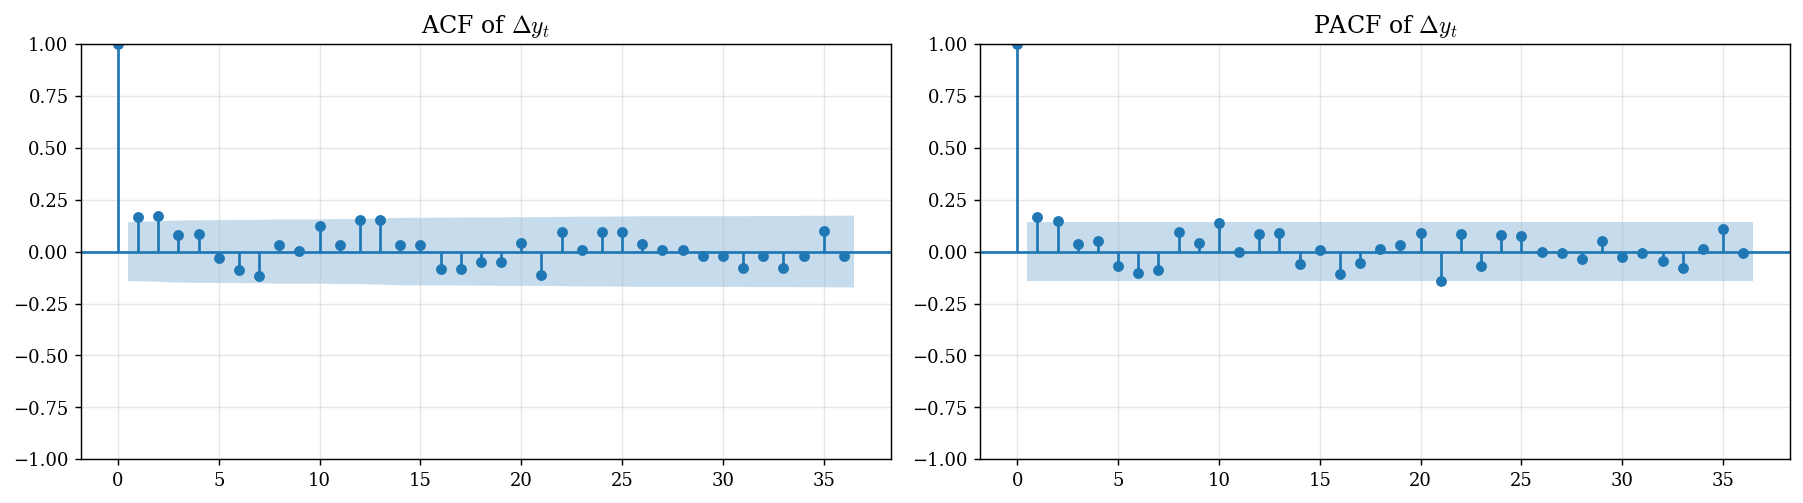

In [10]:
y_diff = df_master['unemployed_rate'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff, lags=36, ax=axes[0], title=r'ACF of $\Delta y_t$')
plot_pacf(y_diff, lags=36, ax=axes[1], title=r'PACF of $\Delta y_t$', method='ywm')
plt.tight_layout()
plt.show()

## 4 $\cdot$ Feature Engineering

Autoregressive lags $y_{t-k}$ (for $k \in \{1,2,3,6,12\}$) and one-step
distributed lags $x_{t-1}$ of key exogenous variables are appended to the
feature set.  This lets regression-type models capture both persistence and
lagged exogenous effects.

In [11]:
df_model = df_master.loc['2010-01-01':].copy()

# Autoregressive lags
for k in [1, 2, 3, 6, 12]:
    df_model[f'y_lag{k}'] = df_model['unemployed_rate'].shift(k)

# Distributed lags of exogenous variables
for col in ['USD_KZT', 'Brent_Oil_Price', 'LaborForce']:
    df_model[f'{col}_lag1'] = df_model[col].shift(1)

df_model.dropna(inplace=True)
print(f"Modeling dataset: {df_model.shape}")
print(f"Date range:       {df_model.index.min().date()} -> {df_model.index.max().date()}")
print(f"Columns:          {list(df_model.columns)}")

Modeling dataset: (180, 16)
Date range:       2011-01-01 -> 2025-12-01
Columns:          ['Agri_Emp', 'Ind_Emp', 'Serv_Emp', 'Nominal_Wage', 'LaborForce', 'Brent_Oil_Price', 'USD_KZT', 'unemployed_rate', 'y_lag1', 'y_lag2', 'y_lag3', 'y_lag6', 'y_lag12', 'USD_KZT_lag1', 'Brent_Oil_Price_lag1', 'LaborForce_lag1']


## 5 $\cdot$ Forecasting Models

### Evaluation Metrics

| Metric | Formula |
|--------|---------|
| MAE | $\frac{1}{n}\sum|y_i - \hat y_i|$ |
| RMSE | $\sqrt{\frac{1}{n}\sum(y_i - \hat y_i)^2}$ |
| $R^2$ | $1 - \frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$ |
| MASE | $\text{MAE}\;/\;\text{MAE}_{\text{naive}}$ |

In [12]:
y = df_model['unemployed_rate']
X = df_model.drop(columns=['unemployed_rate'])

y_train = y.loc[:'2023-12-01']
y_test  = y.loc['2024-01-01':]
X_train = X.loc[:'2023-12-01']
X_test  = X.loc['2024-01-01':]

forecasts = {}
results_list = []

def evaluate(name, actual, predicted, train_y):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    naive_mae = np.mean(np.abs(np.diff(train_y)))
    mase = mae / naive_mae if naive_mae > 0 else np.nan
    print(f'[{name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  MASE={mase:.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MASE': mase}

print(f'Train: {y_train.index.min().date()} -> {y_train.index.max().date()} | n={len(y_train)}')
print(f'Test:  {y_test.index.min().date()} -> {y_test.index.max().date()} | n={len(y_test)}')
print(f'Train target range: {y_train.min():.2f} - {y_train.max():.2f}')
print(f'Test  target range: {y_test.min():.2f} - {y_test.max():.2f}')

Train: 2011-01-01 -> 2023-12-01 | n=156
Test:  2024-01-01 -> 2025-12-01 | n=24
Train target range: 4.70 - 5.60
Test  target range: 4.60 - 4.70


### Model 1 — SARIMA$(2,1,1)(1,1,1)_{12}$

Pure univariate time-series baseline.  No exogenous information — forecasts rely
solely on the autoregressive structure and seasonal pattern of $y_t$.

In [13]:
sarima = SARIMAX(
    y_train, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12),
    trend='c', enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima.fit(disp=False)

sarima_pred = sarima_res.get_forecast(steps=len(y_test)).predicted_mean
sarima_pred.index = y_test.index
forecasts['SARIMA'] = sarima_pred
results_list.append(evaluate('SARIMA', y_test, sarima_pred, y_train))

print(sarima_res.summary())

[SARIMA]  MAE=0.0760  RMSE=0.0868  R2=-3.0192  MASE=5.6105
                                     SARIMAX Results                                      
Dep. Variable:                    unemployed_rate   No. Observations:                  156
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 234.342
Date:                            Mon, 30 Mar 2026   AIC                           -454.685
Time:                                    16:55:36   BIC                           -434.666
Sample:                                01-01-2011   HQIC                          -446.551
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4.932e-05      0.000      0.382      0.702 

### Model 2 — SARIMAX$(2,1,1)(1,1,1)_{12}$ + exogenous

Same seasonal ARIMA structure augmented with exogenous regressors:
$\text{USD/KZT}$, Brent oil price, and labour-force size.

In [14]:
exog_cols = ['USD_KZT', 'Brent_Oil_Price', 'LaborForce']

sarimax = SARIMAX(
    y_train, exog=X_train[exog_cols],
    order=(2, 1, 1), seasonal_order=(1, 1, 1, 12),
    trend='c', enforce_stationarity=False, enforce_invertibility=False)
sarimax_res = sarimax.fit(disp=False)

sarimax_pred = sarimax_res.get_forecast(
    steps=len(y_test), exog=X_test[exog_cols]).predicted_mean
sarimax_pred.index = y_test.index
forecasts['SARIMAX'] = sarimax_pred
results_list.append(evaluate('SARIMAX', y_test, sarimax_pred, y_train))

print(sarimax_res.summary())

[SARIMAX]  MAE=0.3694  RMSE=0.4820  R2=-122.9219  MASE=27.2623
                                     SARIMAX Results                                      
Dep. Variable:                    unemployed_rate   No. Observations:                  156
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 207.795
Date:                            Mon, 30 Mar 2026   AIC                           -395.590
Time:                                    16:55:37   BIC                           -366.992
Sample:                                01-01-2011   HQIC                          -383.970
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept        5.088e-05      0.001    

### Model 3 — ARDL (Autoregressive Distributed Lag)

Econometric specification estimated via OLS with heteroskedasticity-robust
(HC1) standard errors:

$$y_t = \alpha + \sum_{k=1}^{3}\beta_k\,y_{t-k} + \gamma' X_t + \delta' X_{t-1} + \varepsilon_t$$

In [15]:
ardl_cols = [
    'y_lag1', 'y_lag2', 'y_lag3',
    'USD_KZT', 'USD_KZT_lag1',
    'Brent_Oil_Price', 'Brent_Oil_Price_lag1',
    'Agri_Emp', 'Serv_Emp', 'LaborForce',
]

X_ardl_train = sm.add_constant(X_train[ardl_cols], has_constant='add')
X_ardl_test  = sm.add_constant(X_test[ardl_cols],  has_constant='add')

ardl_ols  = sm.OLS(y_train, X_ardl_train).fit(cov_type='HC1')
ardl_pred = pd.Series(ardl_ols.predict(X_ardl_test), index=y_test.index)
forecasts['ARDL'] = ardl_pred
results_list.append(evaluate('ARDL', y_test, ardl_pred, y_train))

print(ardl_ols.summary())

[ARDL]  MAE=0.0381  RMSE=0.0456  R2=-0.1095  MASE=2.8086
                            OLS Regression Results                            
Dep. Variable:        unemployed_rate   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     367.1
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.23e-97
Time:                        16:55:37   Log-Likelihood:                 299.06
No. Observations:                 156   AIC:                            -576.1
Df Residuals:                     145   BIC:                            -542.6
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

### Models 4–6 — Regularised Linear Models

| Model | Penalty | Purpose |
|-------|---------|---------|
| **Elastic Net** | $\alpha\bigl[\lambda\|w\|_1 + \tfrac{1-\lambda}{2}\|w\|_2^2\bigr]$ | Combined L1+L2; automatic feature selection |
| **Ridge** | $\alpha\|w\|_2^2$ | L2 shrinkage; handles multicollinearity |
| **Lasso** | $\alpha\|w\|_1$ | L1 sparsity; drops irrelevant features |

All hyper-parameters are chosen by leave-one-out or 5-fold cross-validation.

In [16]:
scaler = StandardScaler()
X_sc_train = scaler.fit_transform(X_train)
X_sc_test  = scaler.transform(X_test)

models = {
    'ElasticNet': ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5,
                               max_iter=10_000),
    'Ridge':      RidgeCV(alphas=np.logspace(-3, 3, 50)),
    'Lasso':      LassoCV(cv=5, max_iter=10_000),
}

for name, model in models.items():
    model.fit(X_sc_train, y_train)
    pred = pd.Series(model.predict(X_sc_test), index=y_test.index)
    forecasts[name] = pred
    results_list.append(evaluate(name, y_test, pred, y_train))

# Feature importance (Elastic Net coefficients)
en = models['ElasticNet']
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coef': en.coef_})
coef_df = coef_df[coef_df['Coef'].abs() > 1e-6].sort_values('Coef', key=abs, ascending=False)
print(f"\nElastic Net selected {len(coef_df)} features:")
print(coef_df.to_string(index=False))

[ElasticNet]  MAE=0.0256  RMSE=0.0317  R2=0.4634  MASE=1.8896
[Ridge]  MAE=0.0478  RMSE=0.0538  R2=-0.5450  MASE=3.5274
[Lasso]  MAE=0.0256  RMSE=0.0317  R2=0.4634  MASE=1.8896

Elastic Net selected 5 features:
             Feature      Coef
              y_lag1  0.163382
            Agri_Emp  0.019012
             y_lag12  0.008244
            Serv_Emp -0.006924
Brent_Oil_Price_lag1 -0.003182


### Model 7 — Artificial Neural Network (MLP)

A feed-forward multi-layer perceptron with architecture
$\text{input} \to 128 \to 64 \to 32 \to 1$.  Training uses Adam optimiser with
early stopping.

[ANN (MLP)]  MAE=1.1051  RMSE=1.2118  R2=-782.1532  MASE=81.5678


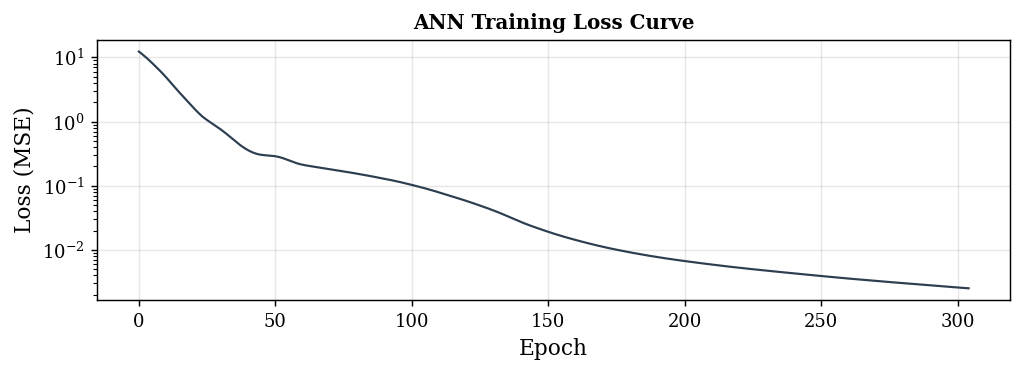

In [17]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
    learning_rate='adaptive',
    learning_rate_init=0.001,
)
mlp.fit(X_sc_train, y_train)

mlp_pred = pd.Series(mlp.predict(X_sc_test), index=y_test.index)
forecasts['ANN (MLP)'] = mlp_pred
results_list.append(evaluate('ANN (MLP)', y_test, mlp_pred, y_train))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(mlp.loss_curve_, color='#2c3e50', lw=1.2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title(r'ANN Training Loss Curve', fontsize=11, fontweight='bold')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Model 8 — Recurrent Neural Network (LSTM)

A Long Short-Term Memory network processes sequences of length
$L = 12$ months.  Architecture: LSTM(64) $\to$ Dropout(0.2) $\to$
LSTM(32) $\to$ Dropout(0.2) $\to$ Dense(1).

$$h_t = \text{LSTM}(x_t,\; h_{t-1})$$

In [18]:
%pip install tensorflow -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


LSTM train: (144, 12, 15)  |  test: (24, 12, 15)
[LSTM]  MAE=0.0790  RMSE=0.0856  R2=-2.9107  MASE=5.8341


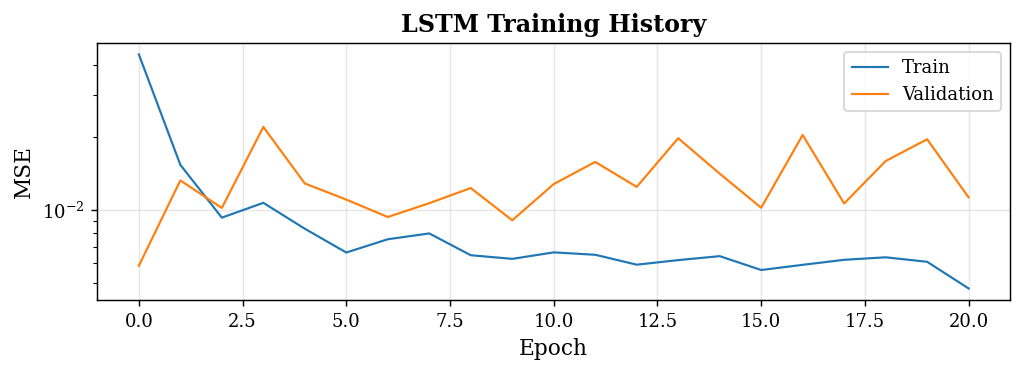

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

LOOKBACK = 12

# Scale features and target separately
sc_X = MinMaxScaler()
sc_y = MinMaxScaler()

feat_cols = [c for c in df_model.columns if c != 'unemployed_rate']
X_all_sc = sc_X.fit_transform(df_model[feat_cols])
y_all_sc = sc_y.fit_transform(df_model[['unemployed_rate']])

# Build sliding-window sequences
X_seq, y_seq, dates = [], [], []
for i in range(LOOKBACK, len(X_all_sc)):
    X_seq.append(X_all_sc[i - LOOKBACK : i])
    y_seq.append(y_all_sc[i, 0])
    dates.append(df_model.index[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
dates = pd.DatetimeIndex(dates)

train_mask = dates <= pd.Timestamp('2023-12-01')
test_mask  = dates >= pd.Timestamp('2024-01-01')

X_tr, y_tr = X_seq[train_mask], y_seq[train_mask]
X_te, y_te = X_seq[test_mask],  y_seq[test_mask]

print(f'LSTM train: {X_tr.shape}  |  test: {X_te.shape}')

tf.random.set_seed(42)
lstm_model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, X_tr.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')

es = EarlyStopping(patience=20, restore_best_weights=True)
history = lstm_model.fit(
    X_tr, y_tr, epochs=200, batch_size=16,
    validation_split=0.15, callbacks=[es], verbose=0)

lstm_pred_sc = lstm_model.predict(X_te, verbose=0)
lstm_pred_vals = sc_y.inverse_transform(lstm_pred_sc).flatten()
lstm_pred = pd.Series(lstm_pred_vals, index=dates[test_mask])
forecasts['LSTM'] = lstm_pred
results_list.append(evaluate('LSTM', y_test.loc[lstm_pred.index], lstm_pred,
                             y_train))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history.history['loss'], label='Train', lw=1.2)
ax.plot(history.history['val_loss'], label='Validation', lw=1.2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('LSTM Training History', fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 6 $\cdot$ Model Comparison

In [20]:
results_df = pd.DataFrame(results_list).set_index('Model')
results_df = results_df.sort_values('MAE')
print(results_df.round(4).to_string())

               MAE    RMSE        R2     MASE
Model                                        
ElasticNet  0.0256  0.0317    0.4634   1.8896
Lasso       0.0256  0.0317    0.4634   1.8896
ARDL        0.0381  0.0456   -0.1095   2.8086
Ridge       0.0478  0.0538   -0.5450   3.5274
SARIMA      0.0760  0.0868   -3.0192   5.6105
LSTM        0.0790  0.0856   -2.9107   5.8341
SARIMAX     0.3694  0.4820 -122.9219  27.2623
ANN (MLP)   1.1051  1.2118 -782.1532  81.5678


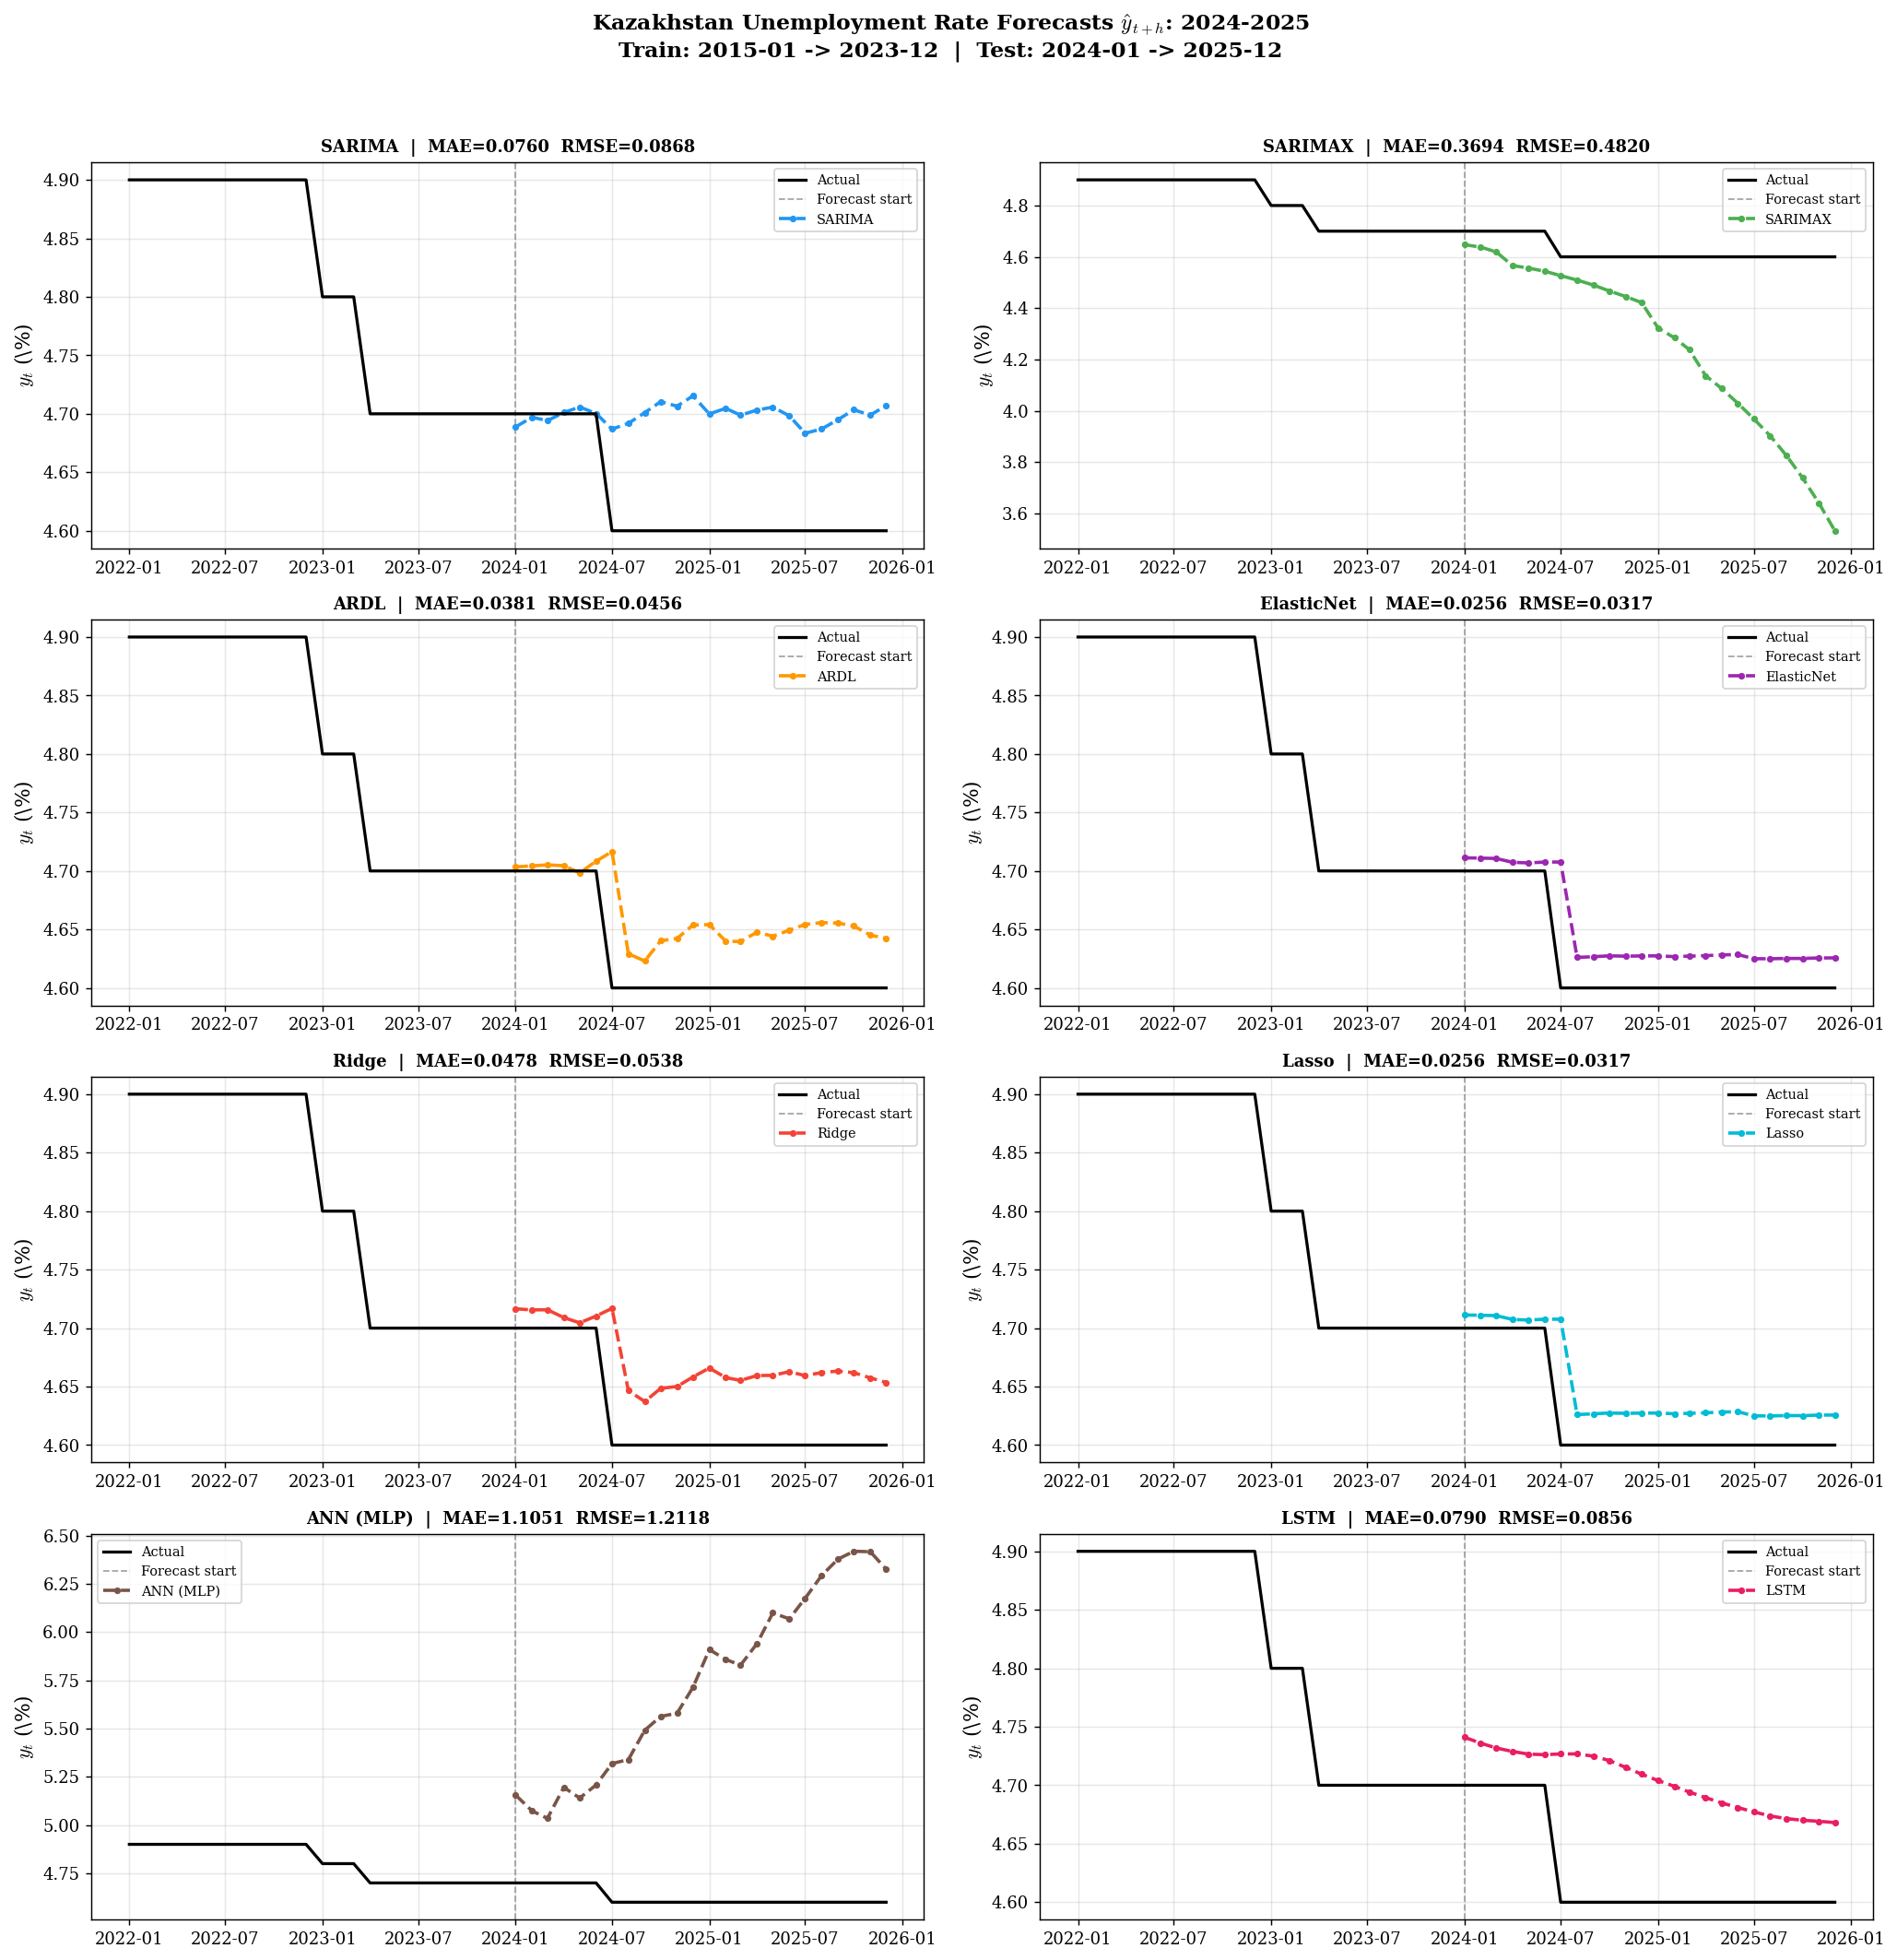

In [21]:
PALETTE = {
    'SARIMA': '#2196F3', 'SARIMAX': '#4CAF50', 'ARDL':   '#FF9800',
    'ElasticNet': '#9C27B0', 'Ridge': '#F44336', 'Lasso': '#00BCD4',
    'ANN (MLP)': '#795548', 'LSTM': '#E91E63',
}

n_models = len(forecasts)
ncols = 2
nrows = (n_models + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, (name, pred) in enumerate(forecasts.items()):
    ax = axes[i]
    ctx = y.loc['2022-01-01':]
    ax.plot(ctx.index, ctx.values, color='black', lw=1.8, label='Actual', zorder=3)
    ax.axvline(pd.Timestamp('2024-01-01'), color='grey', ls='--', alpha=.7,
               lw=1, label='Forecast start')
    ax.plot(pred.index, pred.values, color=PALETTE.get(name, '#999'),
            lw=2, ls='--', marker='o', ms=3, label=f'{name}')

    mae_v  = mean_absolute_error(y.loc[pred.index], pred)
    rmse_v = np.sqrt(mean_squared_error(y.loc[pred.index], pred))
    ax.set_title(f'{name}  |  MAE={mae_v:.4f}  RMSE={rmse_v:.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel(r'$y_t$ (\%)')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    r'Kazakhstan Unemployment Rate Forecasts $\hat{y}_{t+h}$: 2024-2025'
    '\nTrain: 2015-01 -> 2023-12  |  Test: 2024-01 -> 2025-12',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

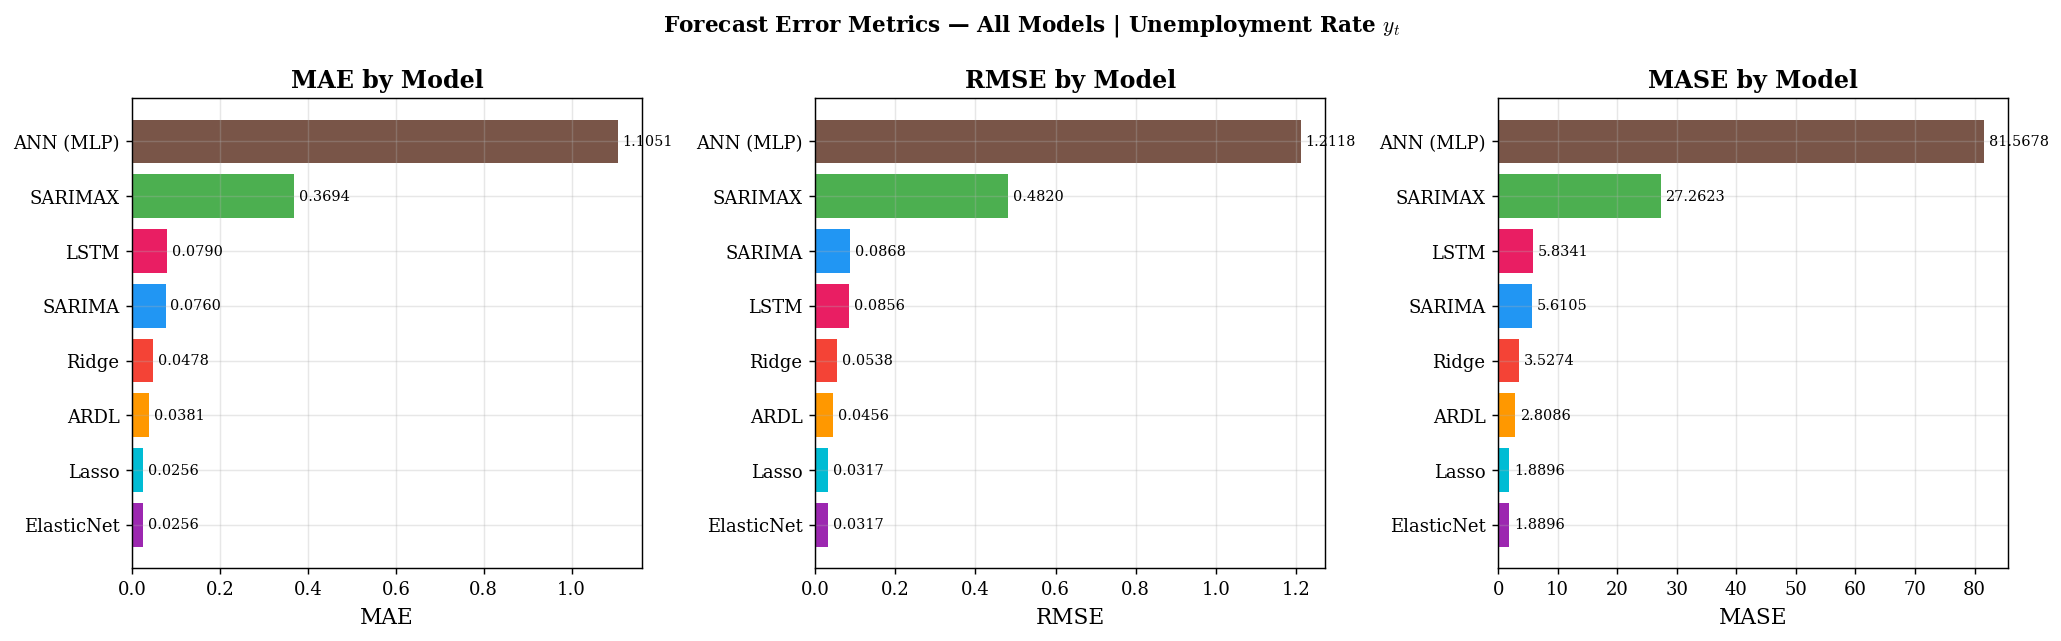

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'MASE']

for ax, m in zip(axes, metrics):
    vals = results_df[m].sort_values()
    colors = [PALETTE.get(idx, '#999') for idx in vals.index]
    bars = ax.barh(vals.index, vals.values, color=colors)
    ax.set_xlabel(m)
    ax.set_title(f'{m} by Model', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, vals.values):
        ax.text(v + vals.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.4f}', va='center', fontsize=8)

plt.suptitle(r'Forecast Error Metrics — All Models | Unemployment Rate $y_t$',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 $\cdot$ Data Sufficiency Assessment

### Current Data Strengths
- **7 structural indicators** covering employment sectors, wages, labour force,
  oil price, and exchange rate
- Monthly frequency from 2010 to 2025 ($n \approx 190$)
- Consistent sources (national statistics + market data)

### Limitations
| Issue | Impact |
|-------|--------|
| Unemployment rate has **only ~7 unique values** (quarterly steps interpolated monthly) | Very low target variance; hard for models to learn fine-grained patterns |
| Most indicators are **annual data PCHIP-interpolated** to monthly | Artificial smoothness; no genuine monthly variation |
| No leading indicators (vacancies, confidence indices) | Cannot capture turning points early |
| $n \approx 190$ monthly observations | Tight for deep learning; overfitting risk |

### Recommended Additional Datasets

| Dataset | Source | Why |
|---------|--------|-----|
| **Job Vacancies / Openings** | stat.gov.kz, enbek.kz | Beveridge-curve dynamics; leading indicator |
| **GDP (quarterly)** | stat.gov.kz, World Bank | Aggregate demand driver of employment |
| **Base Interest Rate** | nationalbank.kz | Monetary policy affects investment $\to$ jobs |
| **Net Migration** | stat.gov.kz | Labour-supply shock; affects unemployment mechanically |
| **Business Confidence / PMI** | IHS Markit, stat.gov.kz | Leading indicator for hiring intentions |
| **Google Trends ("job search KZ")** | trends.google.com | Real-time proxy for labour-market stress |
| **Regional unemployment** | stat.gov.kz | Panel structure increases $n$ dramatically |
| **Education enrolment** | stat.gov.kz | Youth labour-supply pipeline |